# 1. Introduction
**1.1 Problem Statement**

Bài toán đặt ra là dự đoán doanh số bán hàng của các sản phẩm tại hệ thống BigMart dựa trên các thông tin về sản phẩm và cửa hàng. Việc dự đoán chính xác doanh số giúp doanh nghiệp tối ưu hóa quản lý tồn kho, lập kế hoạch kinh doanh và xây dựng các chiến lược marketing hiệu quả.

** 1.2 Objective**

Mục tiêu của nghiên cứu là xây dựng mô hình học máy có khả năng dự đoán doanh số bán hàng (Item_Outlet_Sales) từ các đặc trưng của sản phẩm và cửa hàng. Trong nghiên cứu này, mô hình Random Forest Regressor được lựa chọn để huấn luyện và đánh giá hiệu quả dự đoán.

** 1.3 Dataset Description**

Nghiên cứu sử dụng bộ dữ liệu BigMart Sales Prediction. Bộ dữ liệu bao gồm thông tin về sản phẩm, đặc điểm cửa hàng và doanh số bán hàng tương ứng. Các thuộc tính chính bao gồm:

Product Information: Item Type, Item Weight, Item Visibility, Item MRP, Item Fat Content.
Outlet Information: Outlet Type, Outlet Size, Outlet Location Type, Outlet Establishment Year.
Target Variable: Item_Outlet_Sales.

Bộ dữ liệu được sử dụng để xây dựng mô hình dự đoán doanh số bán hàng và đánh giá hiệu quả của thuật toán Random Forest Regressor.

# 2.Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Data preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Machine Learning Model
from sklearn.ensemble import RandomForestRegressor

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# 3.Load Dataset
Mục tiêu đọc tập dữ liệu Train.csv vào môi trường làm việc và kiểm tra xem dữ liệu đã được tải thành công hay chưa.

In [2]:

df = pd.read_csv("Train.csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
df.tail()#hienthi5donhangcuoi

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976
8522,DRG01,14.800,Low Fat,0.044878,Soft Drinks,75.4670,OUT046,1997,Small,Tier 1,Supermarket Type1,765.6700


In [4]:
#kichthuoc
print("Dataset Shape:", df.shape)

Dataset Shape: (8523, 12)


In [5]:
#caccot
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

# 4. Exploratory Data Analysis (EDA)
Mục tiêu

Khám phá dữ liệu nhằm hiểu rõ cấu trúc, chất lượng và đặc điểm của tập dữ liệu trước khi tiến hành tiền xử lý và xây dựng mô hình.

**4.1. Exploratory Data Analysis (EDA)**

In [6]:
#Kiểm tra số lượng dòng, số lượng cột, kiểu dữ liệu và số lượng giá trị không bị thiếu của từng thuộc tính.
df.dtypes


Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object

In [7]:
# giá trị trung bình, độ lệch chuẩn, giá trị lớn nhất, nhỏ nhất
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [8]:
df.describe(include='object')

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,8523,8523,8523,8523,6113,8523,8523
unique,1559,5,16,10,3,3,4
top,FDW13,Low Fat,Fruits and Vegetables,OUT027,Medium,Tier 3,Supermarket Type1
freq,10,5089,1232,935,2793,3350,5577


In [9]:
# Missing values percentage
(df.isnull().sum()/len(df)*100).sort_values(ascending=False)

Outlet_Size                  28.276428
Item_Weight                  17.165317
Item_Identifier               0.000000
Item_Fat_Content              0.000000
Item_Visibility               0.000000
Item_Type                     0.000000
Item_MRP                      0.000000
Outlet_Identifier             0.000000
Outlet_Establishment_Year     0.000000
Outlet_Location_Type          0.000000
Outlet_Type                   0.000000
Item_Outlet_Sales             0.000000
dtype: float64

In [10]:


print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [11]:

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())


Item_Identifier
['FDA15' 'DRC01' 'FDN15' ... 'NCF55' 'NCW30' 'NCW05']

Item_Fat_Content
['Low Fat' 'Regular' 'low fat' 'LF' 'reg']

Item_Type
['Dairy' 'Soft Drinks' 'Meat' 'Fruits and Vegetables' 'Household'
 'Baking Goods' 'Snack Foods' 'Frozen Foods' 'Breakfast'
 'Health and Hygiene' 'Hard Drinks' 'Canned' 'Breads' 'Starchy Foods'
 'Others' 'Seafood']

Outlet_Identifier
['OUT049' 'OUT018' 'OUT010' 'OUT013' 'OUT027' 'OUT045' 'OUT017' 'OUT046'
 'OUT035' 'OUT019']

Outlet_Size
['Medium' nan 'High' 'Small']

Outlet_Location_Type
['Tier 1' 'Tier 3' 'Tier 2']

Outlet_Type
['Supermarket Type1' 'Supermarket Type2' 'Grocery Store'
 'Supermarket Type3']


**4.2.Quan sát sự phân bố của các biến số và phát hiện sự lệch phân phối.**

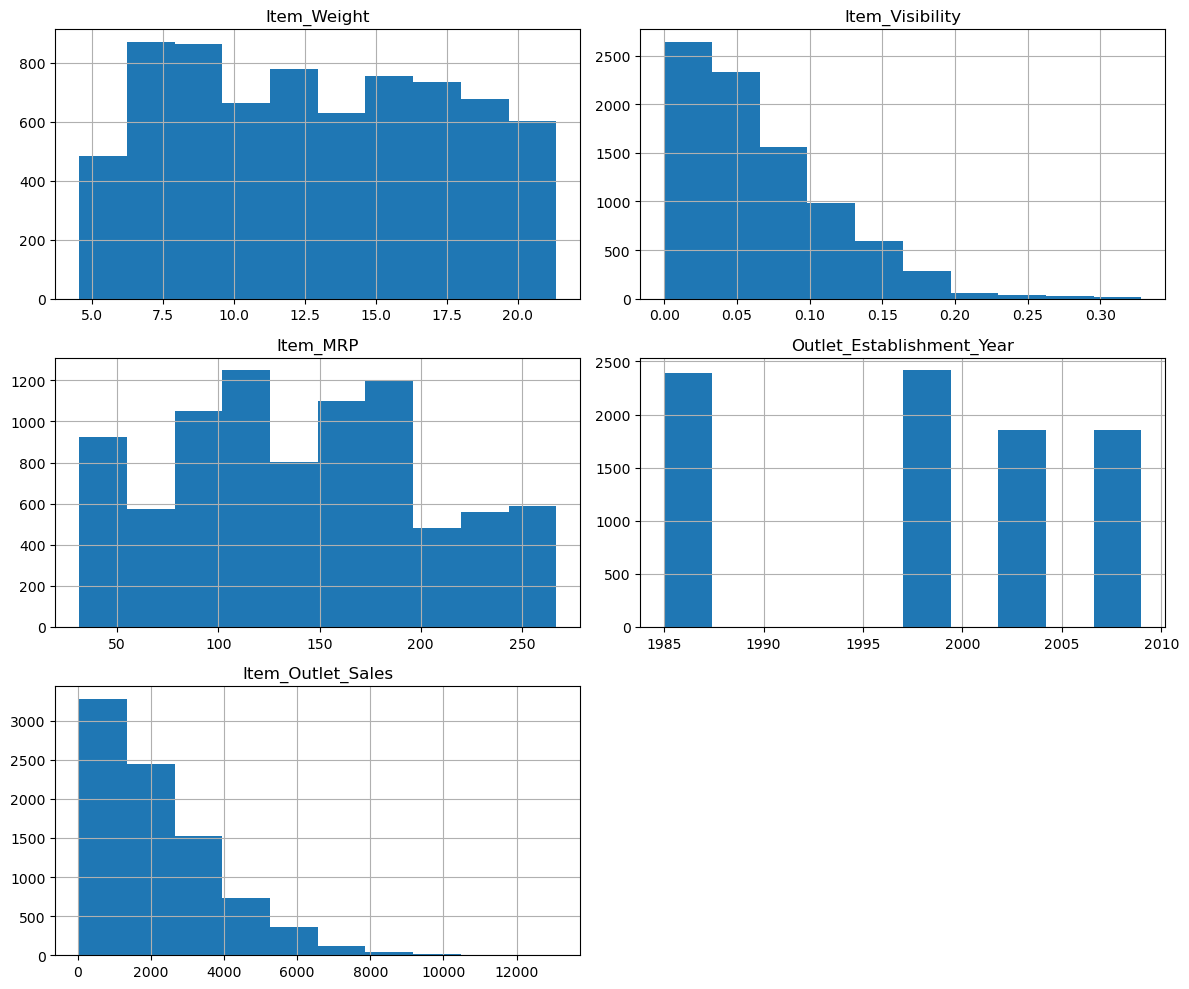

In [12]:

numerical_columns = df.select_dtypes(include=['int64','float64']).columns

df[numerical_columns].hist(figsize=(12,10))

plt.tight_layout()

plt.show()

**4.3.Phát hiện các giá trị ngoại lai (Outliers) của từng thuộc tính số.**

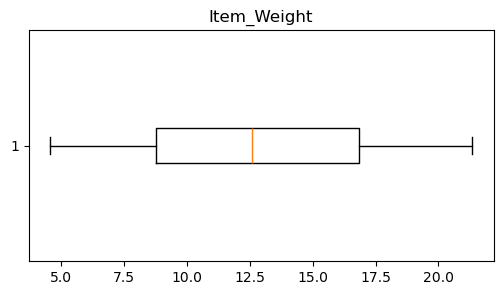

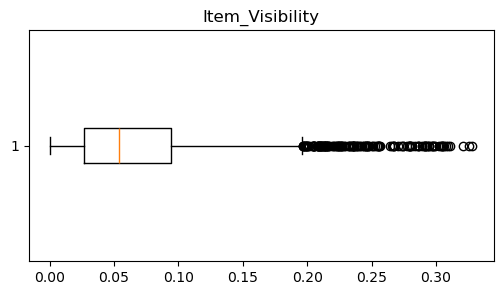

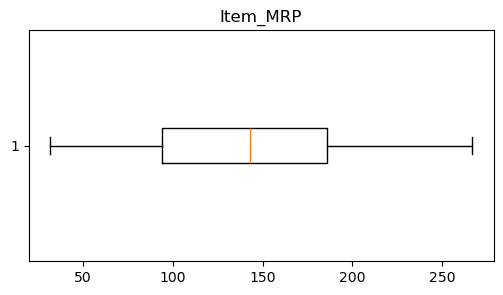

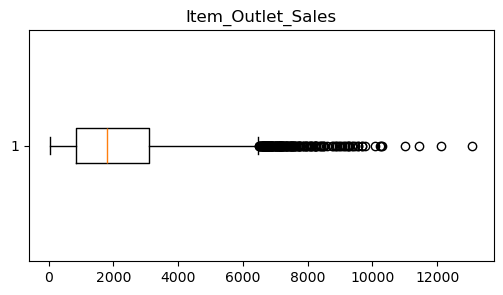

In [13]:


numerical_columns = [
    'Item_Weight',
    'Item_Visibility',
    'Item_MRP',
    'Item_Outlet_Sales'
]

for col in numerical_columns:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(col)
    plt.show()

In [14]:

correlation = df.select_dtypes(include=['int64', 'float64']).corr()

# Display correlation matrix
print(correlation)

                           Item_Weight  Item_Visibility  Item_MRP  \
Item_Weight                   1.000000        -0.014048  0.027141   
Item_Visibility              -0.014048         1.000000 -0.001315   
Item_MRP                      0.027141        -0.001315  1.000000   
Outlet_Establishment_Year    -0.011588        -0.074834  0.005020   
Item_Outlet_Sales             0.014123        -0.128625  0.567574   

                           Outlet_Establishment_Year  Item_Outlet_Sales  
Item_Weight                                -0.011588           0.014123  
Item_Visibility                            -0.074834          -0.128625  
Item_MRP                                    0.005020           0.567574  
Outlet_Establishment_Year                   1.000000          -0.049135  
Item_Outlet_Sales                          -0.049135           1.000000  


# 5. Data Cleaning

Xác định các cột chứa dự liệu bí thiếu 

In [15]:


df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [16]:
# Fill missing values in Item_Weight with mean
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

In [17]:
# Fill missing values in Outlet_Size with mode
df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

In [18]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

**5.2 Standardize Categorical Values**

Chuẩn hóa các giá trị không thống nhất trong Item_Fat_Content.

In [19]:
df['Item_Fat_Content'].unique()

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

In [20]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF':'Low Fat',
    'low fat':'Low Fat',
    'reg':'Regular'
})

In [21]:
df['Item_Fat_Content'].unique()

array(['Low Fat', 'Regular'], dtype=object)

**5.4 Handle Invalid Values**

In [22]:
(df['Item_Visibility']==0).sum()

526

In [23]:
df['Item_Visibility'] = df['Item_Visibility'].replace(0,np.nan)

In [24]:
df['Item_Visibility'] = df['Item_Visibility'].fillna(df['Item_Visibility'].mean())

In [25]:
(df['Item_Visibility']==0).sum()

0

**5.5 Verify Cleaned Data**

Kiểm tra dữ liệu sau khi làm sạch

In [26]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

# 6. Feature Engineering

"Mục đích của bước này là tạo ra các tính năng (biến số) hữu ích và chuyển đổi các biến phân loại thành các giá trị số để mô hình học máy có thể sử dụng được."

**6.1 Create a New Feature (Outlet_Age)**

Chuyển năm thành lập cửa hàng thành tuổi cửa hàng, vì tuổi cửa hàng phản ánh rõ hơn thời gian hoạt động

In [27]:

df['Outlet_Age'] = 2026 - df['Outlet_Establishment_Year']


**6.2 Label Encoding**

In [28]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    'Item_Fat_Content',
    'Item_Type',
    'Outlet_Size',
    'Outlet_Location_Type',
    'Outlet_Type'
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

In [29]:
df.drop(
    columns=[
        'Item_Identifier',
        'Outlet_Identifier'
    ],
    inplace=True
)

**6.2 Encode Categorical Features**

In [30]:


encoder = LabelEncoder()

categorical_columns = [
    'Item_Fat_Content',
    'Item_Type',
    'Outlet_Size',
    'Outlet_Location_Type',
    'Outlet_Type'
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])
  

In [31]:
df.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
0,9.30,0,0.016047,4,249.8092,1999,1,0,1,3735.1380,27
1,5.92,1,0.019278,14,48.2692,2009,1,2,2,443.4228,17
2,17.50,0,0.016760,10,141.6180,1999,1,0,1,2097.2700,27
3,19.20,1,0.070482,6,182.0950,1998,1,2,0,732.3800,28
4,8.93,0,0.070482,9,53.8614,1987,0,2,1,994.7052,39


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Weight                8523 non-null   float64
 1   Item_Fat_Content           8523 non-null   int64  
 2   Item_Visibility            8523 non-null   float64
 3   Item_Type                  8523 non-null   int64  
 4   Item_MRP                   8523 non-null   float64
 5   Outlet_Establishment_Year  8523 non-null   int64  
 6   Outlet_Size                8523 non-null   int64  
 7   Outlet_Location_Type       8523 non-null   int64  
 8   Outlet_Type                8523 non-null   int64  
 9   Item_Outlet_Sales          8523 non-null   float64
 10  Outlet_Age                 8523 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 732.6 KB


# 7. Train-Test Split

"Tách bộ dữ liệu thành các tính năng đầu vào ($X$) và biến mục tiêu ($y$), sau đó chia dữ liệu thành các tập dữ liệu huấn luyện (training set) và tập dữ liệu kiểm thử (testing set) để phục vụ cho việc phát triển và đánh giá mô hình."

**7.1 Define Features and Target**
Tách dữ liệu thành:

X: Các đặc trưng (Features).
y: Biến mục tiêu (Item_Outlet_Sales).

In [33]:


# Features
X = df.drop('Item_Outlet_Sales', axis=1)

# Target
y = df['Item_Outlet_Sales']

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (8523, 10)
Target Shape: (8523,)


**7.2 Split the Dataset**

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**7.3 Verify the Split**

In [37]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (6818, 10)
X_test : (1705, 10)
y_train: (6818,)
y_test : (1705,)


# 8. Model Training

**8.1 Linear Regression**

In [38]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

**8.2 Decision Tree**

In [39]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

**8.3 Random Forest**

In [40]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

# 9. Model Evaluation

So sánh hiệu suất của các mô hình hồi quy đã được huấn luyện trên tập dữ liệu thử nghiệm. Việc đánh giá dựa trên các chỉ số MAE, MSE, RMSE và R² để xác định mô hình phù hợp nhất cho việc dự đoán doanh số bán sản phẩm.

**9.1 Predict on Testing Data**

In [41]:

linear_pred = linear_model.predict(X_test)

tree_pred = tree_model.predict(X_test)

rf_pred = rf_model.predict(X_test)


**9.2 Calculate Evaluation Metrics**
Tính các chỉ số đánh giá gồm:

MAE (Mean Absolute Error)
MSE (Mean Squared Error)
RMSE (Root Mean Squared Error)
R² Score

In [42]:

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'MAE': [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, tree_pred),
        mean_absolute_error(y_test, rf_pred)
    ],

    'MSE': [
        mean_squared_error(y_test, linear_pred),
        mean_squared_error(y_test, tree_pred),
        mean_squared_error(y_test, rf_pred)
    ],

    'RMSE': [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, tree_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],

    'R2 Score': [
        r2_score(y_test, linear_pred),
        r2_score(y_test, tree_pred),
        r2_score(y_test, rf_pred)
    ]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,857.248309,1.295340e+06,1138.130104,0.523416
1,Decision Tree,1019.207811,2.146123e+06,1464.965330,0.210395
2,Random Forest,754.445479,1.170743e+06,1082.008899,0.569258


**9.3 Compare Model Performance**

In [43]:
print(results)

               Model          MAE           MSE         RMSE  R2 Score
0  Linear Regression   857.248309  1.295340e+06  1138.130104  0.523416
1      Decision Tree  1019.207811  2.146123e+06  1464.965330  0.210395
2      Random Forest   754.445479  1.170743e+06  1082.008899  0.569258


Random Forest
MAE = 754.45 (thấp nhất)
RMSE = 1082.01 (thấp nhất)
R² = 0.5693 (cao nhất)

→ Đây là mô hình có hiệu quả dự đoán tốt nhất trong ba thuật toán. Việc kết hợp nhiều cây quyết định giúp giảm overfitting và cải thiện độ chính xác.

→ Dựa trên kết quả đánh giá, mô hình Random Forest Regressor đạt hiệu suất tốt nhất trong ba mô hình được thử nghiệm. Mô hình này có MAE = 754.45, RMSE = 1082.01 và R² Score = 0.5693, cho thấy sai số dự đoán thấp nhất và khả năng giải thích dữ liệu cao nhất. Vì vậy, Random Forest Regressor được lựa chọn là mô hình cuối cùng để dự đoán doanh số sản phẩm trong bài toán BigMart Sales Prediction.

**9.4Feature Importance**

Mô hình Random Forest xem yếu tố nào ảnh hướng nhiều nhất tới danh số bán hàng


Feature Importance:


,Feature,Importance
0,Item_MRP,0.453457
1,Outlet_Type,0.231223
2,Item_Visibility,0.113007
3,Item_Weight,0.057625
4,Item_Type,0.046954
5,Outlet_Age,0.045195
6,Outlet_Establishment_Year,0.024084
7,Item_Fat_Content,0.009797
8,Outlet_Size,0.009520
9,Outlet_Location_Type,0.009138


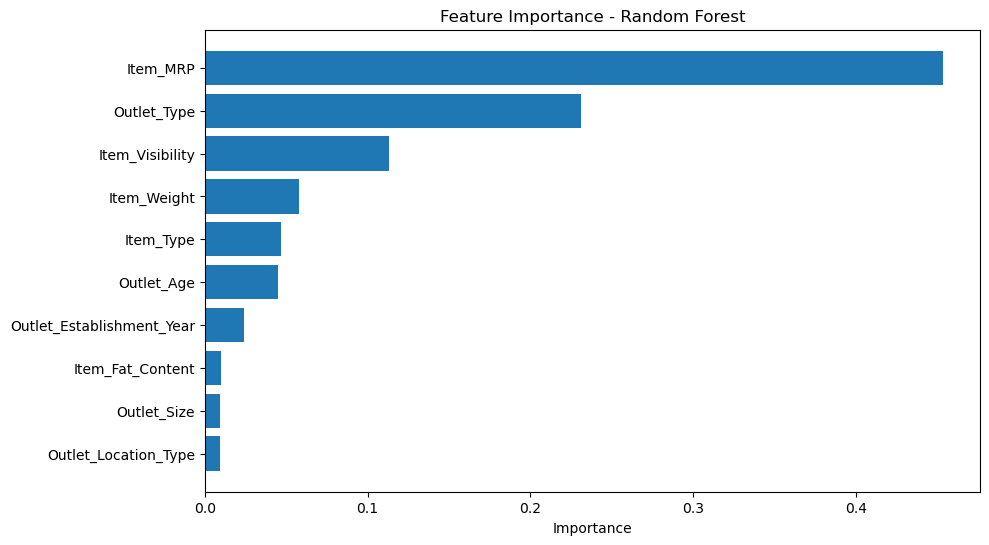

In [44]:

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Feature Importance:")
display(importance)
plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

## 10 Feature Importance Analysis 
Random Forest Regressor không chỉ có khả năng dự đoán doanh số bán hàng với độ chính xác cao mà còn cho phép xác định mức độ quan trọng (Feature Importance) của từng đặc trưng trong quá trình dự đoán. Việc phân tích Feature Importance giúp em hiểu rõ đặc trưng nào ảnh hưởng nhiều nhất đến doanh số bán hàng, từ đó hỗ trợ việc đưa ra các quyết định kinh doanh phù hợp.

Sau khi huấn luyện mô hình Random Forest Regressor, chúng em tiến hành trích xuất và phân tích mức độ quan trọng của các đặc trưng đầu vào. Kết quả cho thấy mức độ ảnh hưởng của các đặc trưng đến biến mục tiêu Item_Outlet_Sales là khác nhau.

Phân tích kết quả Feature Importance

Dựa trên kết quả thu được, một số đặc trưng có ảnh hưởng lớn đến doanh số bán hàng gồm:

Item_MRP: Đây là đặc trưng quan trọng nhất, cho thấy giá bán sản phẩm có ảnh hưởng lớn nhất đến doanh số. Điều này phù hợp với thực tế vì giá cả là một trong những yếu tố quyết định hành vi mua sắm của khách hàng.
Outlet_Type: Loại hình cửa hàng có mức độ ảnh hưởng cao đến doanh số. Mỗi loại cửa hàng phục vụ những nhóm khách hàng khác nhau nên sẽ tạo ra mức doanh số khác nhau.
Item_Visibility: Mức độ hiển thị của sản phẩm cũng ảnh hưởng đáng kể đến doanh số. Những sản phẩm được trưng bày ở vị trí dễ quan sát thường có khả năng được khách hàng lựa chọn nhiều hơn.
Item_Weight, Item_Type và Outlet_Age (hoặc Outlet_Establishment_Year): Các đặc trưng này có mức độ ảnh hưởng trung bình, góp phần hỗ trợ mô hình trong quá trình dự đoán doanh số.

Trong khi đó, các đặc trưng như Outlet_Location_Type, Outlet_Size và Item_Fat_Content có mức độ ảnh hưởng thấp hơn, cho thấy chúng không phải là những yếu tố quyết định chính đối với doanh số bán hàng trong bộ dữ liệu BigMart.

Nhận xét

Kết quả phân tích Feature Importance cho thấy mô hình Random Forest không chỉ mang lại khả năng dự đoán tốt mà còn giúp giải thích được mức độ đóng góp của từng đặc trưng. Qua đó, em nhận thấy giá sản phẩm (Item_MRP) và loại hình cửa hàng (Outlet_Type) là hai yếu tố ảnh hưởng mạnh nhất đến doanh số bán hàng.

Tuy nhiên, cần lưu ý rằng giá trị Feature Importance chỉ phản ánh mức độ ảnh hưởng tương đối trong mô hình Random Forest và có thể thay đổi khi dữ liệu hoặc các tham số của mô hình thay đổi.

## 11. Conclusion 

Trong bài thực hành này, nhóm đã xây dựng thành công mô hình dự đoán doanh số bán hàng (Item_Outlet_Sales) dựa trên bộ dữ liệu BigMart thông qua đầy đủ các bước của quy trình Machine Learning, bao gồm khám phá dữ liệu (EDA), xử lý dữ liệu, tạo đặc trưng, chia tập dữ liệu, lựa chọn mô hình, huấn luyện và đánh giá kết quả.

Đánh giá hiệu quả các mô hình

Trong quá trình thực hiện, nhóm đã thử nghiệm ba thuật toán hồi quy gồm Linear Regression, Decision Tree Regressor và Random Forest Regressor.

Kết quả đánh giá dựa trên các chỉ số MAE, MSE, RMSE và R² Score cho thấy Random Forest Regressor đạt hiệu suất tốt nhất. Mô hình này có sai số dự đoán thấp hơn và khả năng giải thích dữ liệu cao hơn so với hai mô hình còn lại. Điều này cho thấy Random Forest phù hợp với bài toán dự đoán doanh số bán hàng trên bộ dữ liệu BigMart.

Các đặc trưng ảnh hưởng đến doanh số

Thông qua phân tích Feature Importance, nhóm nhận thấy một số đặc trưng có ảnh hưởng lớn đến doanh số bán hàng gồm:

Item_MRP là đặc trưng quan trọng nhất, cho thấy giá bán sản phẩm có tác động lớn đến doanh số.
Outlet_Type là yếu tố quan trọng thứ hai, phản ánh ảnh hưởng của loại hình cửa hàng đến khả năng tiêu thụ sản phẩm.
Item_Visibility cũng có mức độ ảnh hưởng đáng kể, cho thấy việc trưng bày sản phẩm hợp lý có thể góp phần nâng cao doanh số.
Ưu điểm và hạn chế của mô hình
Ưu điểm
Xử lý tốt dữ liệu có nhiều đặc trưng và mối quan hệ phi tuyến.
Giảm hiện tượng overfitting nhờ kết hợp nhiều cây quyết định.
Cho kết quả dự đoán ổn định và có độ chính xác cao.
Hạn chế
Thời gian huấn luyện dài hơn so với các mô hình đơn giản như Linear Regression.
Khó giải thích chi tiết cơ chế dự đoán so với mô hình tuyến tính.
Hiệu quả của mô hình vẫn phụ thuộc vào việc lựa chọn các tham số phù hợp.
Hướng phát triển

Trong tương lai, nhóm có thể cải thiện mô hình bằng các hướng sau:

Tối ưu siêu tham số (Hyperparameter Tuning) bằng Grid Search hoặc Random Search.
Bổ sung thêm dữ liệu hoặc xây dựng thêm các đặc trưng mới để nâng cao độ chính xác.
Thử nghiệm thêm các thuật toán khác như Gradient Boosting, XGBoost hoặc LightGBM để so sánh và lựa chọn mô hình tối ưu hơn.
Kết luận

Qua kết quả thực nghiệm, nhóm nhận thấy Random Forest Regressor là mô hình phù hợp nhất cho bài toán dự đoán doanh số bán hàng trên bộ dữ liệu BigMart. Mô hình không chỉ đạt hiệu suất dự đoán cao mà còn cung cấp thông tin về mức độ quan trọng của từng đặc trưng, giúp việc phân tích dữ liệu và hỗ trợ ra quyết định trong kinh doanh trở nên hiệu quả hơn. So với Linear Regression và Decision Tree Regressor, Random Forest cho kết quả dự đoán chính xác và ổn định hơn, do đó được lựa chọn là mô hình cuối cùng trong nghiên cứu này.